In [ ]:
#import
import rasterio
import os
import numpy as np
import pandas as pd
import glob
from osgeo import gdal
import rioxarray as rxr
import matplotlib.pyplot as plt
import fiona
import rasterio.mask


#from scripts.raster_prep_copy import out_dir


In [94]:
# set directory
dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405"

In [95]:
lidar = glob.glob(os.path.join(dir, "lidar","*.tif"))
print(lidar)

['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405\\lidar\\SNEX_MCS_Lidar_20230405_SD_V01.0_filtered_mw20_smooth3.tif']


In [135]:
modeled = os.path.join(dir, "modeled")

In [136]:

HMS_EB = glob.glob(os.path.join(modeled, "*EB_snow_depth*.tif"))[0]
HMS_TI = glob.glob(os.path.join(modeled, "*TI_snow_depth*.tif"))[0]

with rasterio.open(HMS_EB) as src:
    raster_data = src.read(1, masked=True).filled(np.nan)
    out_raster = raster_data * 0.0254
                # Include model in output filename
    out_path = os.path.join(modeled, "HMS_EB_inches.tif")
    profile = src.profile
    with rasterio.open(out_path, "w", **profile) as dest:
            dest.write(out_raster.astype("float32"), 1)

with rasterio.open(HMS_TI) as src:
    raster_data = src.read(1, masked=True).filled(np.nan)
    out_raster = raster_data * 0.0254
                # Include model in output filename
    out_path = os.path.join(modeled, "HMS_TI_inches.tif")
    profile = src.profile
    with rasterio.open(out_path, "w", **profile) as dest:
            dest.write(out_raster.astype("float32"), 1)



In [137]:
rasters = {
    "HMS_EB": glob.glob(os.path.join(modeled, "*EB_inches*.tif")),
    "HMS_TI": glob.glob(os.path.join(modeled, "*TI_inches*.tif")),
    "iSnobal": glob.glob(os.path.join(modeled, "*thickness*.tif")),
    "SnowModel": glob.glob(os.path.join(modeled, "*snod*.tif")),
}

print(rasters)

{'HMS_EB': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405\\modeled\\HMS_EB_inches.tif'], 'HMS_TI': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405\\modeled\\HMS_TI_inches.tif'], 'iSnobal': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405\\modeled\\thickness_2023-04-05T23_00_00.tif'], 'SnowModel': ['C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405\\modeled\\snod_746_04-05-2023_12.tif']}


In [138]:
MCS = os.path.join(dir, "MCS_outline/basin_outline.shp")

with fiona.open(MCS, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

In [143]:
out_dir = os.path.join(dir, "outputs")
stats_list = []

# Loop by model
for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
            out_meta = src.meta.copy()

        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
        })

        # Include model in output filename
        out_name = os.path.basename(raster).replace(".tif", f"_{model}_MCS.tif")
        out_path = os.path.join(out_dir, out_name)

        with rasterio.open(out_path, "w", **out_meta) as dest:
            dest.write(out_image)

# Compute statistics
        data = out_image[0]  # 1 band raster, extract 2D array
        mask = (data == -9999)
        data_masked = np.ma.array(data, mask=mask)  # mask nodata

        raster_stats = {
            "file": out_name,
            "model": model,
            "min": data_masked.min(),
            "mean": data_masked.mean(),
            "max": data_masked.max(),
            "zeros": np.sum(data_masked == 0)
        }
        
        stats_list.append(raster_stats)


# Convert stats to a DataFrame
stats_df = pd.DataFrame(stats_list)
stats_csv = os.path.join(out_dir, "raster_stats.csv")
stats_df.to_csv(stats_csv, index=False)


In [140]:
outputs = os.path.join(dir, "outputs")

rasters = {
    "HMS_EB": glob.glob(os.path.join(outputs, "*EB_snow_depth*.tif")),
    "HMS_TI": glob.glob(os.path.join(outputs, "*TI_snow_depth*.tif")),
    "iSnobal": glob.glob(os.path.join(outputs, "*thickness*.tif")),
    "SnowModel": glob.glob(os.path.join(outputs, "*snod*.tif")),
}

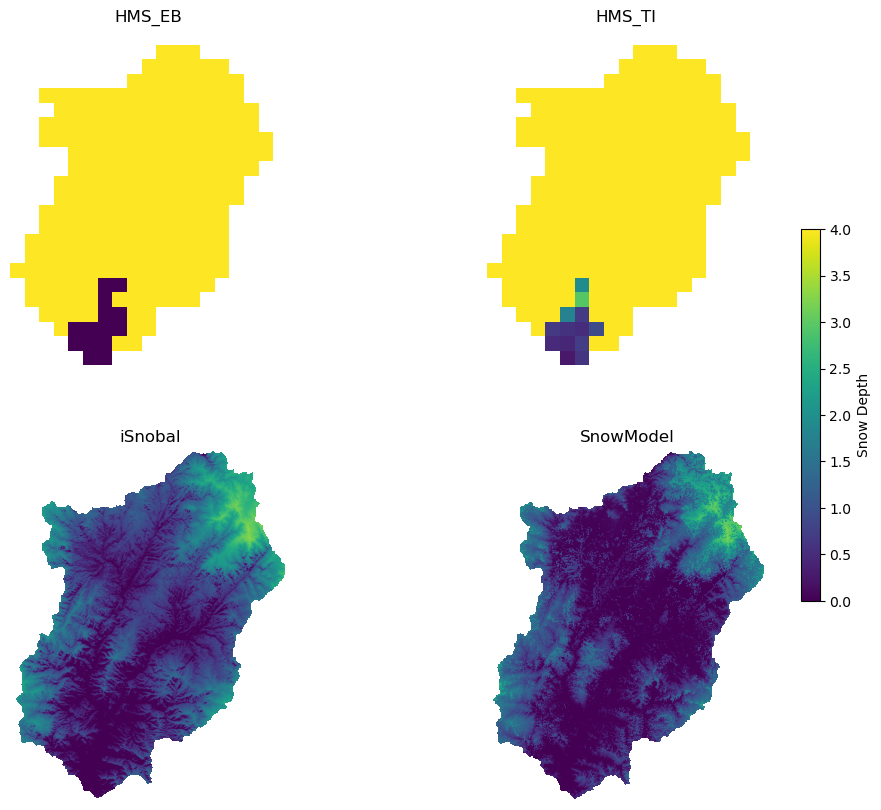

In [141]:
# Pick the first raster from each model (for plotting)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # flatten to 1D array for easy looping

for i, (model, raster_list) in enumerate(rasters.items()):
    raster_path = raster_list[0] 
    
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis", extent=extent, vmin=0,vmax=4.0 )
    axes[i].set_title(model)
    axes[i].axis("off")

# Add colorbar
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, pad=0.04, label="Snow Depth")

plt.show()

In [105]:
dfs = []

for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            data = src.read(1, masked=True)
            mask = (data == -9999)
            data_masked = np.ma.array(data, mask=mask)  # mask nodata
            flattened = data_masked.compressed()
            
        # convert to DataFrame
            df = pd.DataFrame({
            "Model": model,        # this column will store model names
            "value": flattened     # this column stores raster values
        })
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)

<Figure size 800x600 with 0 Axes>

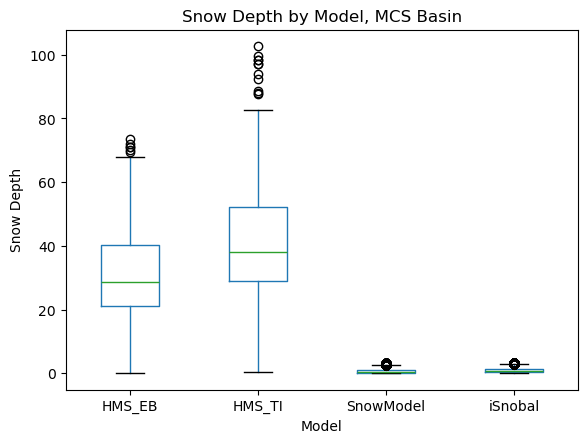

In [106]:
plt.figure(figsize=(8, 6))
all_data.boxplot(column="value", by="Model", grid=False)  # make sure column name matches
plt.ylabel("Snow Depth")
plt.title("Snow Depth by Model, MCS Basin")
plt.suptitle("")  # remove automatic title

# Save figure before showing
plt.savefig(os.path.join(outputs, "raster_boxplot.png"), dpi=300, bbox_inches="tight")

plt.show()

In [ ]:

# Save to file
plt.savefig(os.path.join(outputs, "raster_boxplot.png"), dpi=300, bbox_inches="tight")  